# Evaluación Sumativa: Inteligencia de Negocios y Análisis de Riesgo Crediticio
**Asignatura:** Minería de Datos  
**Metodología:** CRISP-DM  
**Dataset:** `credit_risk_dataset.csv` — 32.581 registros, 12 variables

---
## FASE 1: Entendimiento del Negocio

### Objetivo Estratégico


>El objetivo es identificar perfiles de clientes con tendencia a la morosidad para proteger la solvencia del banco. Un falso negativo (prestar a quien no pagará) es crítico porque genera una pérdida directa del capital, costos operativos de cobranza y un alto costo de oportunidad para la institución.


### Planteamiento de Hipótesis de Negocio


> **Hipótesis A:** Los clientes con un ingreso anual (`person_income`) bajo presentan una tasa de morosidad significativamente mayor que el promedio.
>
> **Hipótesis B:** Existe una correlación directa entre la calificación del préstamo (`loan_grade`) y el impago; a medida que la letra avanza (de A hacia G), aumenta la morosidad.


---
## FASE 2: Entendimiento de los Datos

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga del archivo
df = pd.read_csv('credit_risk_dataset.csv')

# 2. Diagnóstico de estructura (Muestra tipos de datos y nulos)
print("--- Información General del Dataset ---")
df.info()

# 3. Vista de los primeros registros
print("\n--- Primeros 5 registros ---")
display(df.head())

# 4. Resumen estadístico (Para detectar ruidos y rangos)
print("\n--- Estadísticas Descriptivas ---")
display(df.describe().round(2))

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage:

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



--- Estadísticas Descriptivas ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00



### Valores Criticos


> De los datos extraidos anteriormente las variables críticas seleccionadas fueron person_income, loan_grade y loan_status, ya que permiten analizar el riesgo crediticio de los clientes.

>person_income representa la capacidad de pago del solicitante, loan_grade indica el nivel de riesgo asignado por el banco y loan_status muestra si el cliente cumplió o no con el pago del préstamo.

>Estas variables son clave para estudiar la relación entre ingresos, riesgo y morosidad bancaria.


### Evaluación de Calidad: Detección de "Ruidos"

A partir del diagnóstico inicial (`df.describe()`), se identificaron valores atípicos (outliers) que evidencian errores de captura:

* **`person_age`:** Registra un valor máximo ilógico de 144 años.
* **`person_emp_length`:** Muestra un máximo de 123 años de antigüedad laboral, superando en muchos casos la edad del cliente.
* **`person_income`:** El ingreso máximo (6.000.000) es desproporcionadamente alto frente al promedio (66.000).

**Impacto en el Modelo Predictivo:**

Ingresar estos datos sin procesar afectará la credibilidad del modelo de las siguientes maneras:

1.  **Distorsión de Cálculos:** Al basarse en distancias matemáticas, los modelos (ej. Regresión Logística) intentarán ajustarse a estos valores extremos, sesgando significativamente sus predicciones.
2.  **Aprendizaje Defectuoso:** El algoritmo podría asignar una importancia incorrecta a la edad o la antigüedad, perdiendo eficacia al evaluar a clientes dentro de rangos normales.
3.  **Falta de Confiabilidad:** Un modelo de riesgo crediticio que procese edades de 144 años sin generar alertas perderá toda validez ante la gerencia.

**Acción:** Es imprescindible una fase de **Limpieza de Datos** para filtrar estos registros antes de entrenar el modelo.

---
## FASE 3: Limpieza y Transformación

### Identificación de Nulos:

> Lo siguiente sera identificar nulos en `person_emp_length` y `loan_int_rate` para esto se calculará la cantidad y el porcentaje de datos faltantes por columna ordenado en una tabla para poder visualizar los datos:

In [2]:
# ── Diagnóstico de valores nulos ───────────────────────────────────────────────
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)

# Creamos una tablita ordenada para visualizarlo
reporte_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct})

# Filtramos para que solo nos muestre las columnas que de verdad tienen vacíos
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0]

print("Variables con valores nulos:")
display(reporte_nulos)

Variables con valores nulos:


,Nulos,% del total
person_emp_length,895,2.75
loan_int_rate,3116,9.56



### Tratamiento de Valores Nulos y Outliers

Con base en el diagnóstico previo, aplicaremos una estrategia mixta para la limpieza del dataset:

**1. Eliminación de Nulos (Drop):**
La variable `person_emp_length` presenta un 2.7% de valores faltantes. Según las mejores prácticas, al ser menor al 5%, se decide **eliminar** estas filas. Esto asegura que el modelo se entrene con datos reales de empleabilidad sin reducir significativamente el volumen general del dataset.

**2. Imputación de Nulos (Fill):**
La variable `loan_int_rate` (tasa de interés) tiene cerca de un 10% de valores faltantes. Eliminar el 10% de la base de clientes representaría una pérdida inaceptable de información. Por lo tanto, se **imputarán** estos valores vacíos utilizando la **mediana**. Se elige la mediana porque es resistente a los valores atípicos y no sesgará la distribución general de las tasas.


In [3]:
# Hacemos una copia del dataset original para trabajar de forma segura
df_clean = df.copy()

# 1. ELIMINAR filas que tengan nulos solo en 'person_emp_length' (el 2.7%)
df_clean = df_clean.dropna(subset=['person_emp_length'])

# 2. IMPUTAR la tasa de interés ('loan_int_rate') con la mediana (el 10%)
mediana_tasa = df_clean['loan_int_rate'].median()
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(mediana_tasa)

# 3. COMPROBACIÓN FINAL
print(f"Filas originales: {len(df)}")
print(f"Filas después de la limpieza: {len(df_clean)}")
print("\nRevisión de Nulos restantes en el dataset limpio:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Filas originales: 32581
Filas después de la limpieza: 31686

Revisión de Nulos restantes en el dataset limpio:


Series([], dtype: int64)

### Gestión de Outliers

El diagnóstico inicial reveló que la variable `person_income` tiene una media cercana a los $66000, pero presenta un valor extremo de 6,000,000. Este tipo de dispersión no representa a la cartera de clientes habitual del banco.

**Aplicación de Filtro Lógico:**
Para evitar que estos ingresos excepcionales sesguen el modelo (otorgando pesos excesivos a unos pocos clientes), aplicaremos el **Método del Rango Intercuartílico (IQR)** para identificar un límite superior matemático, complementado con un criterio de negocio.

En lugar de eliminar ciegamente los datos por encima de un número arbitrario, se establecerá un tope en **150.000**, lo que permite mantener a la inmensa mayoría de la población (los clientes reales que el banco necesita evaluar) mientras se aísla el "ruido extremo" que podría corromper la regresión predictiva.

In [6]:
# 1. Analizar cómo se distribuyen los ingresos altos
print("--- Análisis de Ingresos ANTES del filtro ---")
print(f"Ingreso máximo original: {df_clean['person_income'].max()}")
# Vemos cuántas personas ganan más de 150.000
personas_ingreso_alto = len(df_clean[df_clean['person_income'] > 150000])
print(f"Personas con ingresos superiores a 150.000: {personas_ingreso_alto} (Serán excluidas para evitar sesgo)\n")

# 2. Aplicar el filtro lógico (Nos quedamos con los ingresos lógicos para el modelo)
# Mantenemos a quienes ganan 150.000 o menos
df_clean = df_clean[df_clean['person_income'] <= 150000]

# 3. Comprobación Final de la Fase 3
print("--- Resultado Final de la Preparación de Datos ---")
print(f"Ingreso máximo tras limpieza: {df_clean['person_income'].max()}")
print(f"Total de filas finales listas para modelar: {len(df_clean)}")

--- Análisis de Ingresos ANTES del filtro ---
Ingreso máximo original: 150000
Personas con ingresos superiores a 150.000: 0 (Serán excluidas para evitar sesgo)

--- Resultado Final de la Preparación de Datos ---
Ingreso máximo tras limpieza: 150000
Total de filas finales listas para modelar: 30560


---
## FASE 4: Análisis Exploratorio de Datos (EDA)

### Análisis de Desbalanceo — Distribución de `loan_status`

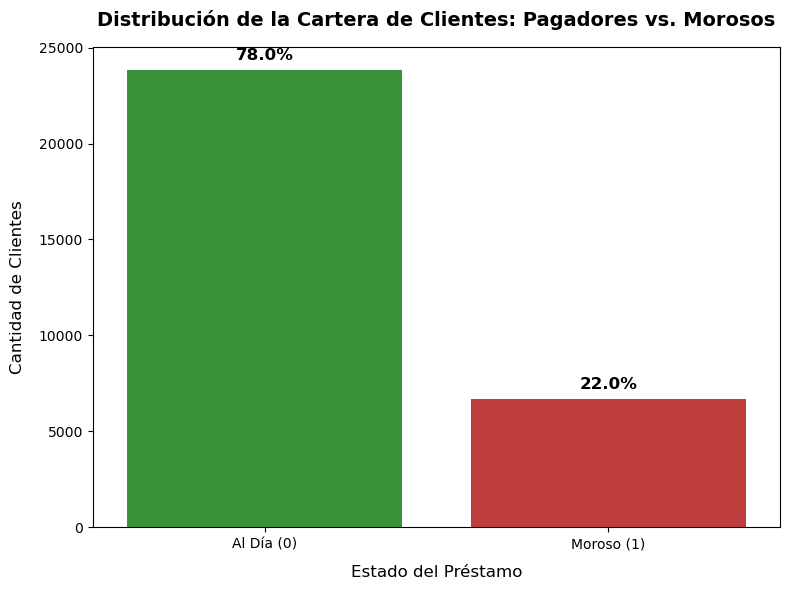

In [7]:
# 1. Tamaño del lienzo
plt.figure(figsize=(8, 6))

# 2. Crear el gráfico
ax = sns.countplot(x='loan_status', hue='loan_status', data=df_clean, 
                   palette=['#2ca02c', '#d62728'], legend=False)

# 3. Textos y títulos
plt.title('Distribución de la Cartera de Clientes: Pagadores vs. Morosos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estado del Préstamo', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Clientes', fontsize=12, labelpad=10)
plt.xticks(ticks=[0, 1], labels=['Al Día (0)', 'Moroso (1)'])

# 4. Agregar los porcentajes al tope de cada barra
total_clientes = len(df_clean)

for p in ax.patches:
    # Obtener la altura de la barra (cantidad de clientes)
    altura = p.get_height()
    # Calcular el porcentaje
    porcentaje = f'{100 * altura / total_clientes:.1f}%'
    
    # Anotar el texto en el gráfico
    ax.annotate(porcentaje,
                (p.get_x() + p.get_width() / 2., altura), # Coordenada (x, y)
                ha='center', va='bottom',                 # Centrado
                fontsize=12, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points') # Separación de 5 puntos hacia arriba

# 5. Asegurar que no haya superposición (overplotting) y mostrar
plt.tight_layout()
plt.show()

### Relación Ingreso vs. Monto del Préstamo

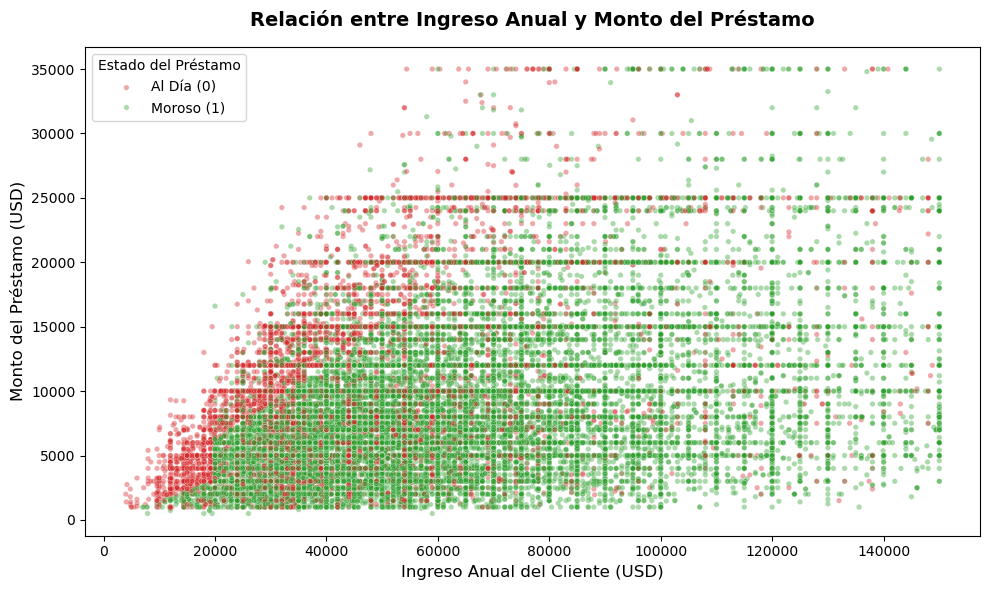

In [8]:
# 1. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 2. Crear el gráfico de dispersión (Scatterplot)
# - alpha=0.4: Hace los puntos semi-transparentes para ver la densidad (evita overplotting)
# - s=15: Hace los puntos más pequeños
# - hue='loan_status': Pinta de distinto color según si pagó o es moroso
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', 
                data=df_clean, palette=['#2ca02c', '#d62728'], alpha=0.4, s=15)

# 3. Títulos y etiquetas profesionales
plt.title('Relación entre Ingreso Anual y Monto del Préstamo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ingreso Anual del Cliente (USD)', fontsize=12)
plt.ylabel('Monto del Préstamo (USD)', fontsize=12)

# 4. Modificar la leyenda para que sea más legible
plt.legend(title='Estado del Préstamo', labels=['Al Día (0)', 'Moroso (1)'])

# Mostrar gráfico
plt.tight_layout()
plt.show()

### Análisis Comparativo — Edad del Cliente vs. Estado del Préstamo

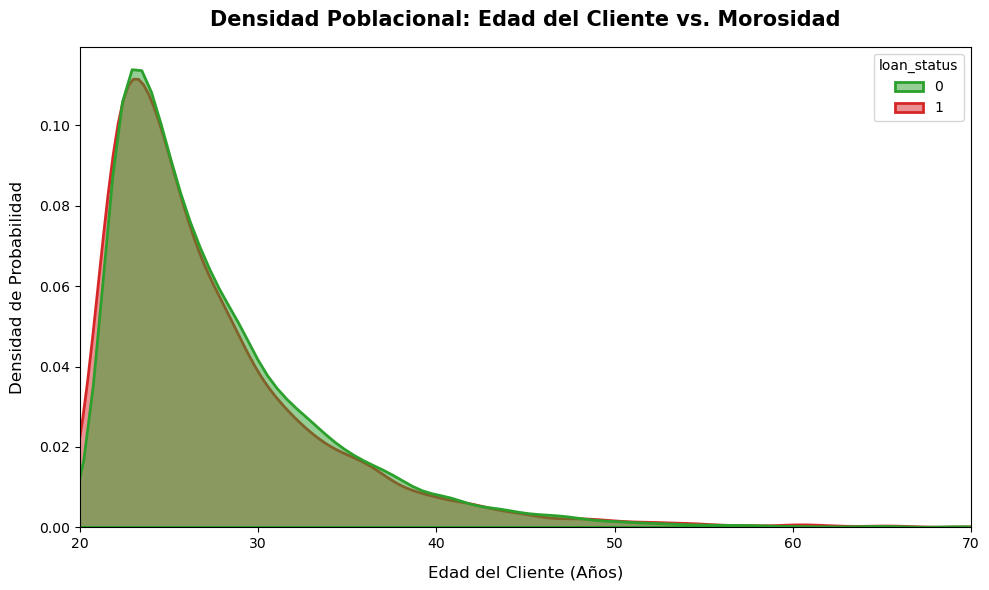

In [9]:
# 1. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 2. Crear el Gráfico de Densidad (KDE)
# - fill=True: Rellena el área bajo la curva para mejor visualización
# - common_norm=False: Escala ambas curvas de forma independiente para poder comparar 
#   sus formas reales, a pesar de que haya más clientes al día que morosos.
# - alpha=0.5: Transparencia para ver dónde se cruzan
sns.kdeplot(data=df_clean, x='person_age', hue='loan_status', 
            fill=True, common_norm=False, palette=['#2ca02c', '#d62728'], alpha=0.5, linewidth=2)

# 3. Títulos y etiquetas
plt.title('Densidad Poblacional: Edad del Cliente vs. Morosidad', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad del Cliente (Años)', fontsize=12, labelpad=10)
plt.ylabel('Densidad de Probabilidad', fontsize=12, labelpad=10)

# 4. Ajustar los límites del eje X para enfocar en la zona más relevante
# Esto elimina el espacio vacío si es que hay muy pocas personas mayores de 70
plt.xlim(20, 70)

# Mostrar gráfico limpio
plt.tight_layout()
plt.show()

### Analisis de Edad del cliente vs Morosidad:

>El grueso de la cartera de clientes del banco está compuesto por jóvenes profesionales. Dado que las curvas de densidad de morosos y no morosos son prácticamente superponibles, la edad es un factor transversal y no un factor de riesgo por sí mismo.

---
### Análisis Hipotesis A: Ingresos vs. Estado del Préstamo

Para someter a prueba nuestra primera hipótesis, necesitamos visualizar si existe una diferencia significativa en los ingresos de los clientes que pagan puntualmente frente a los que caen en mora. 

Utilizaremos un **Diagrama de Caja (Boxplot)** con el parámetro `hue` para segmentar por estado del préstamo. Gracias a la limpieza previa (donde acotamos los ingresos a un máximo lógico de 150.000), este gráfico mostrará claramente las medianas y la dispersión del 50% central de los clientes.

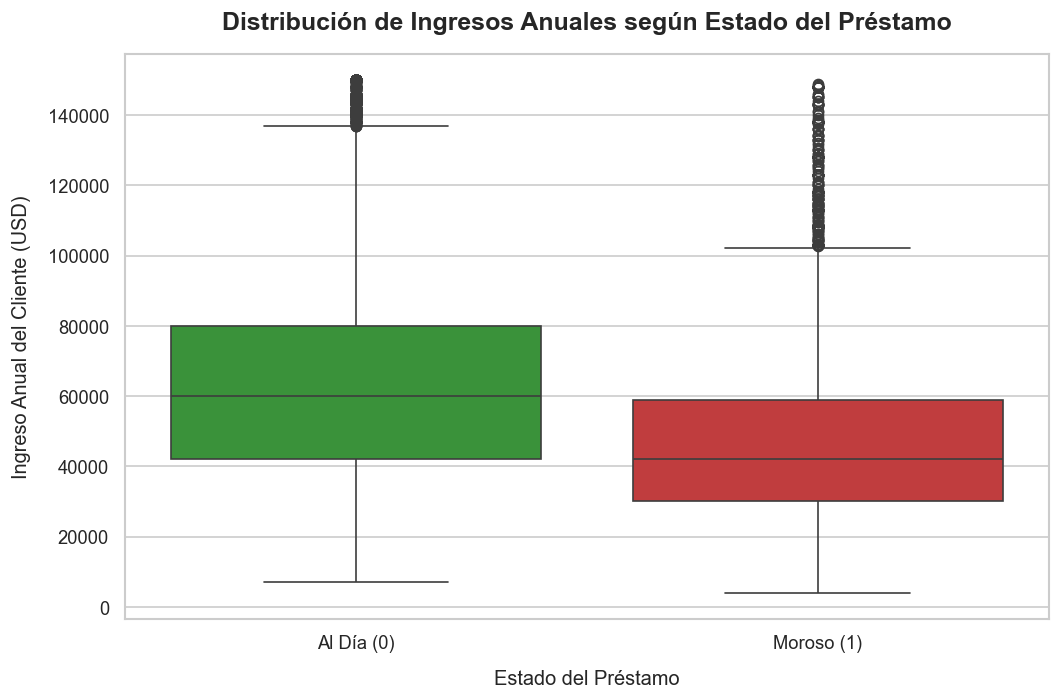

In [15]:
# 1. Configurar el tamaño del lienzo
plt.figure(figsize=(9, 6))

# 2. Crear el Boxplot
# Usamos 'hue' para diferenciar claramente ambos grupos con la paleta semántica
sns.boxplot(x='loan_status', y='person_income', hue='loan_status', data=df_clean, 
            palette=['#2ca02c', '#d62728'], legend=False)

# 3. Títulos y etiquetas profesionales
plt.title('Distribución de Ingresos Anuales según Estado del Préstamo', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Estado del Préstamo', fontsize=12, labelpad=10)
plt.ylabel('Ingreso Anual del Cliente (USD)', fontsize=12, labelpad=10)

# Formatear el eje X para mayor claridad
plt.xticks(ticks=[0, 1], labels=['Al Día (0)', 'Moroso (1)'])

# Mostrar gráfico limpio
plt.tight_layout()
plt.show()

---
### 4.5 Análisis Hipotesis B: Calificación del Préstamo vs. Morosidad

Para someter a prueba nuestra segunda hipótesis, analizaremos el comportamiento de pago en función de la calificación de riesgo asignada al préstamo (`loan_grade`). 

Generaremos primero una tabla de contingencia para calcular la tasa exacta de morosidad por cada grado. Luego, lo visualizaremos mediante un gráfico de barras agrupadas ordenado lógicamente de menor a mayor riesgo (A -> G).

--- Tasa de Morosidad por Grado Crediticio ---


,% Al Día,% Morosos
loan_grade,,
A,90.2,9.8
B,83.6,16.4
C,79.1,20.9
D,40.3,59.7
E,35.1,64.9
F,28.6,71.4
G,1.6,98.4


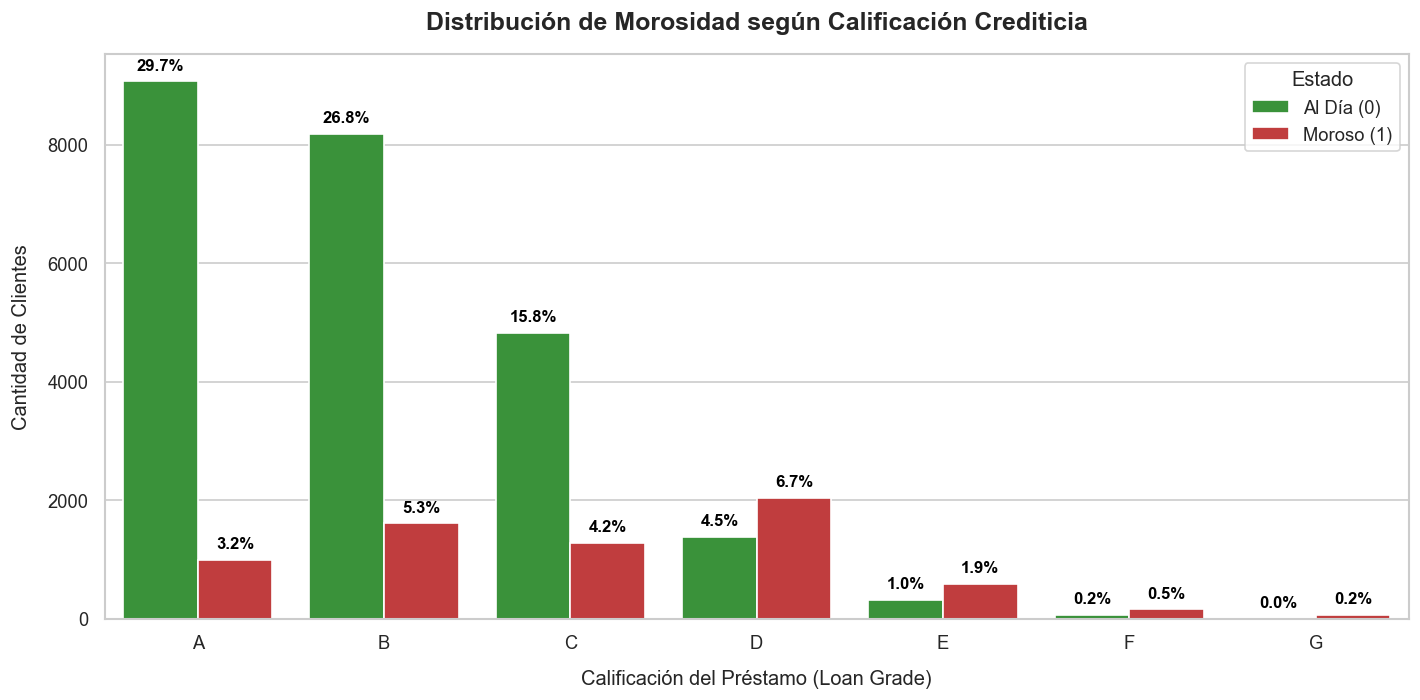

In [16]:
# 1. Crear una tabla cruzada para ver la tasa de morosidad exacta por grado
tabla_grados = pd.crosstab(df_clean['loan_grade'], df_clean['loan_status'], normalize='index') * 100
tabla_grados.columns = ['% Al Día', '% Morosos']
print("--- Tasa de Morosidad por Grado Crediticio ---")
display(tabla_grados.round(1))

# 2. Configurar el lienzo para el gráfico
plt.figure(figsize=(12, 6))
orden_grados = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# 3. Crear el gráfico comparativo
ax = sns.countplot(x='loan_grade', hue='loan_status', data=df_clean, 
                   order=orden_grados, palette=['#2ca02c', '#d62728'])

# 4. Títulos y etiquetas
plt.title('Distribución de Morosidad según Calificación Crediticia', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Calificación del Préstamo (Loan Grade)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Clientes', fontsize=12, labelpad=10)
plt.legend(title='Estado', labels=['Al Día (0)', 'Moroso (1)'], loc='upper right')

# 5. Agregar los porcentajes (sobre el total de esa barra)
total_clientes = len(df_clean)
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Evitar errores si una categoría está vacía
        porcentaje = f'{100 * altura / total_clientes:.1f}%'
        ax.annotate(porcentaje,
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color='black',
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

---
## FASE 5: Síntesis y Decisiones

### Validación de Hipótesis

>
> **Hipótesis A: Impacto del Ingreso Anual en la Morosidad**  
> Basándonos en el gráfico de "Distribución de Ingresos Anuales según Estado del Préstamo", se observa una diferencia clara en los niveles de renta. La mediana de ingresos de los clientes morosos (barra roja) se sitúa sensiblemente por debajo de la de los clientes solventes (barra verde), los bajos ingresos son un indicador directo de riesgo. Los clientes con menos "colchón financiero" tienen una mayor probabilidad de incumplimiento ante cualquier imprevisto económico.
>
> **Hipótesis B: Correlación entre Calificación Crediticia y Morosidad**  
> Al analizar la Tasa de Morosidad por Grado Crediticio y su respectivo gráfico de barras, la evidencia es contundente. La hipotesis se confirma ya que en los grados A y B la morosidad es mínima y la barra de solvencia es dominante, a partir del Grado D la relación se invierte drásticamente. En los grados más bajos (E, F y G), la proporción de morosos supera con creces a la de los clientes que pagan.

### 5.2 Recomendación de Negocio

>**3. Política de Inclusión Financiera (Eliminación de Sesgo por Edad):**
* **El Problema:** Existe el sesgo cognitivo de que los jóvenes son inherentemente peores pagadores.
* **La Decisión:** El análisis de densidad comprobó que la edad no separa a los buenos pagadores de los morosos (ambos grupos se concentran en torno a los 26 años). El banco debe asegurar que su algoritmo de evaluación y sus políticas comerciales **no penalicen a los solicitantes jóvenes** basándose únicamente en su edad. La evaluación debe centrarse estrictamente en métricas de capacidad de pago e historial crediticio.